In [1]:
# PyTorch 및 이미지 처리 라이브러리
import torch
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version :", torch.__version__)
print("Torchvision version :", torchvision.__version__)


PyTorch version : 2.13.0+cpu
Torchvision version : 0.28.0+cpu


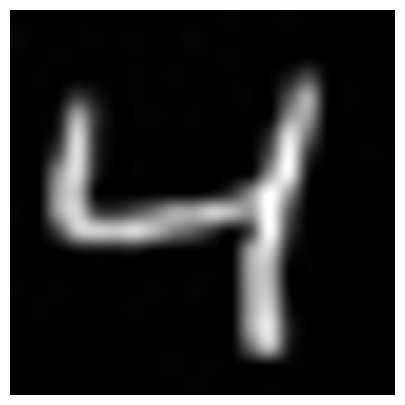

PIL image size : (224, 224)
img_tensor.shape : torch.Size([3, 224, 224])


In [2]:
# 2. 이미지 로드 및 전처리
img_path = "data/four.jpg"

src = Image.open(img_path).convert("RGB").resize((244, 244))
plt.figure(figsize=(5, 5))
plt.imshow(src)
plt.axis("off")
plt.show()

img = Image.open(img_path).convert("RGB").resize((224, 224))
print("PIL image size :", img.size)

# PyTorch는 이미지 데이터를 기본적으로 [C, H, W] 형태의 Tensor로 사용한다.
img_tensor = transforms.ToTensor()(img)
print("img_tensor.shape :", img_tensor.shape)


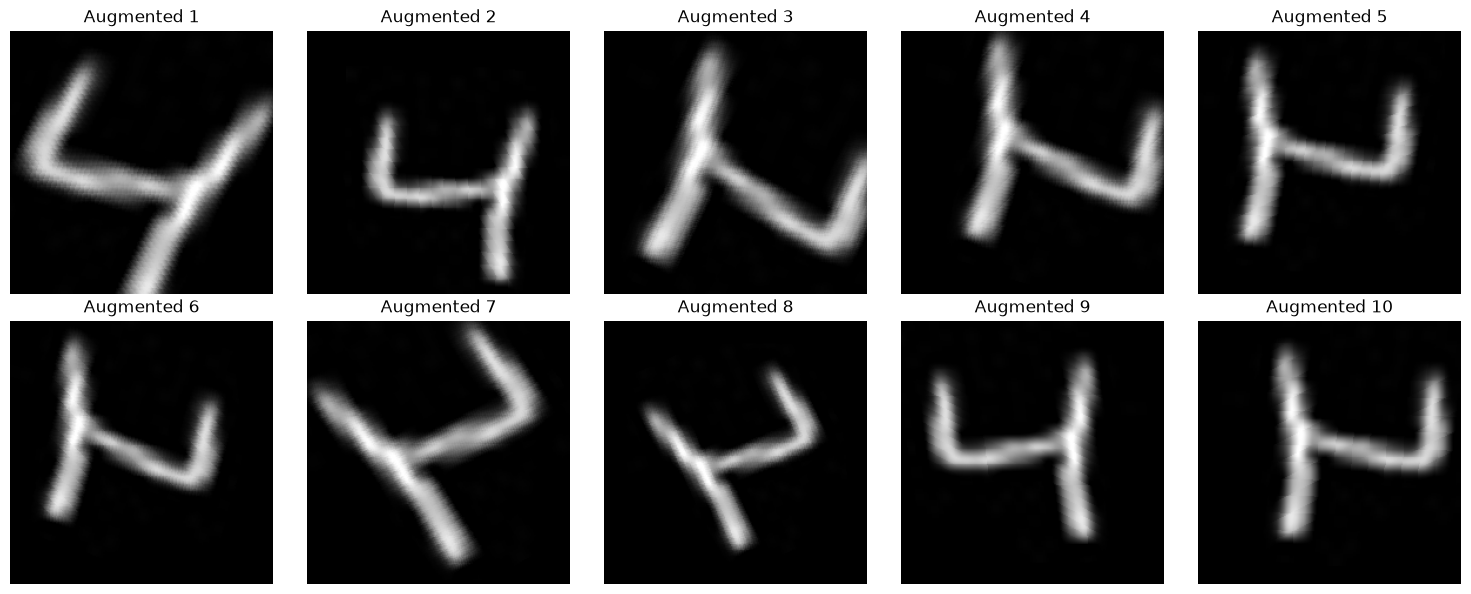

In [3]:
# 3. PyTorch 데이터 증강 설정
# Keras의 ImageDataGenerator에 대응하는 torchvision 변환이다.

augment_transform = transforms.Compose([
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        shear=(-10, 10),
        scale=(0.8, 1.2)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
])

# 동일한 원본 이미지에 매번 랜덤 변환을 적용한다.
augmented_images = []

for _ in range(10):
    aug_img = augment_transform(img)
    augmented_images.append(aug_img)

# 4. 증강 이미지 10개 시각화
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, aug_img in enumerate(augmented_images):
    axes[i].imshow(aug_img)
    axes[i].axis("off")
    axes[i].set_title(f"Augmented {i+1}")

plt.tight_layout()
plt.show()


In [4]:
# MNIST 데이터셋 다운로드 및 로드
mnist_train_raw = datasets.MNIST(
    root="./data",
    train=True,
    download=True
)

mnist_test_raw = datasets.MNIST(
    root="./data",
    train=False,
    download=True
)

print("학습 데이터 :", len(mnist_train_raw))
print("테스트 데이터 :", len(mnist_test_raw))


학습 데이터 : 60000
테스트 데이터 : 10000


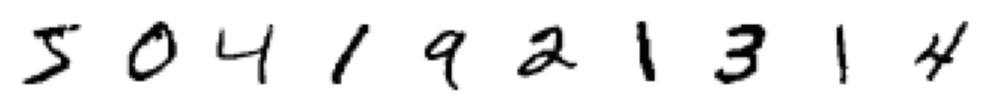

In [7]:
# 격자 형태로 이미지를 출력하는 함수
def draw_images(n, data):
    fig, ax = plt.subplots(
        1, n,
        sharex=True,
        sharey=True,
        figsize=(10, 2)
    )

    if n == 1:
        ax = [ax]

    for i in range(n):
        image = data[i]
        if torch.is_tensor(image):
            image = image.squeeze().cpu().numpy()

        ax[i].imshow(image, cmap="Greys")
        ax[i].axis("off")

    plt.tight_layout()
    plt.show()

draw_images(10, mnist_train_raw.data)



In [8]:
# 데이터셋의 정보 요약
X_train = mnist_train_raw.data
y_train = mnist_train_raw.targets

X_test = mnist_test_raw.data
y_test = mnist_test_raw.targets

print("학습 데이터 :", X_train.shape, y_train.shape)
print("테스트 데이터 :", X_test.shape, y_test.shape)

print(f"학습 데이터의 최소값 : {X_train.min().item()}")
print(f"학습 데이터의 최대값 : {X_train.max().item()}")
print(f"학습 데이터의 평균값 : {X_train.float().mean().item():.4f}")
print(f"학습 데이터의 표준편차 : {X_train.float().std().item():.4f}")



학습 데이터 : torch.Size([60000, 28, 28]) torch.Size([60000])
테스트 데이터 : torch.Size([10000, 28, 28]) torch.Size([10000])
학습 데이터의 최소값 : 0
학습 데이터의 최대값 : 255
학습 데이터의 평균값 : 33.3184
학습 데이터의 표준편차 : 78.5675
